In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import math
import random
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')
rc('axes', axisbelow=True)

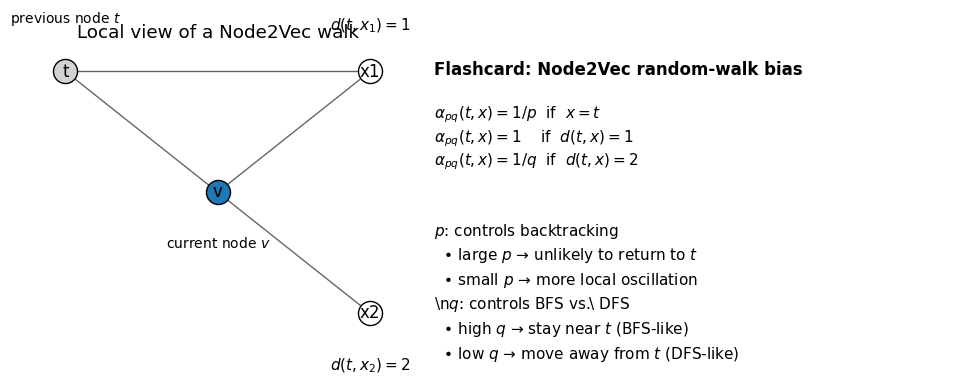

In [5]:
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 11

# Build a tiny example graph: t -- v -- x1, v -- x2, and t -- x1
G = nx.Graph()
G.add_edges_from([
    ("t", "v"),
    ("v", "x1"),
    ("v", "x2"),
    ("t", "x1"),
])

pos = {
    "t":  (0.0,  0.5),
    "v":  (1.5,  0.0),
    "x1": (3.0,  0.5),
    "x2": (3.0, -0.5),
}

fig, axes = plt.subplots(1, 2, gridspec_kw={"width_ratios": [1.1, 1.6]})
ax_graph, ax_text = axes

# --- Left panel: toy graph ---

nx.draw_networkx_edges(G, pos, ax=ax_graph, alpha=0.6)

nx.draw_networkx_nodes(G, pos, nodelist=["t"], node_color="lightgray",
                       edgecolors="black", ax=ax_graph)
nx.draw_networkx_nodes(G, pos, nodelist=["v"], node_color="tab:blue",
                       edgecolors="black", ax=ax_graph)
nx.draw_networkx_nodes(G, pos, nodelist=["x1", "x2"], node_color="white",
                       edgecolors="black", ax=ax_graph)

nx.draw_networkx_labels(G, pos, ax=ax_graph)

ax_graph.text(pos["x1"][0], pos["x1"][1] + 0.15, r"$d(t,x_1)=1$",
              ha="center", va="bottom")
ax_graph.text(pos["x2"][0], pos["x2"][1] - 0.18, r"$d(t,x_2)=2$",
              ha="center", va="top")
ax_graph.text(pos["v"][0], pos["v"][1] - 0.18, r"current node $v$",
              ha="center", va="top", fontsize=10)
ax_graph.text(pos["t"][0], pos["t"][1] + 0.18, r"previous node $t$",
              ha="center", va="bottom", fontsize=10)

ax_graph.set_title("Local view of a Node2Vec walk")
ax_graph.set_axis_off()

# --- Right panel: formula + intuition ---

ax_text.set_axis_off()

# Title for the flashcard
ax_text.text(
    0.0, 0.95,
    r"Flashcard: Node2Vec random-walk bias",
    ha="left", va="top", fontsize=12, fontweight="bold"
)

# Piecewise definition as separate lines (no \begin{cases})
ax_text.text(
    0.0, 0.80,
    r"$\alpha_{pq}(t,x) = 1/p$  if  $x = t$",
    ha="left", va="top"
)
ax_text.text(
    0.0, 0.72,
    r"$\alpha_{pq}(t,x) = 1$    if  $d(t,x)=1$",
    ha="left", va="top"
)
ax_text.text(
    0.0, 0.64,
    r"$\alpha_{pq}(t,x) = 1/q$  if  $d(t,x)=2$",
    ha="left", va="top"
)

# Verbal intuition
explanation = (
    r"$p$: controls backtracking" "\n"
    r"  • large $p$ → unlikely to return to $t$" "\n"
    r"  • small $p$ → more local oscillation" "\n"
    r"\n"
    r"$q$: controls BFS vs.\ DFS" "\n"
    r"  • high $q$ → stay near $t$ (BFS-like)" "\n"
    r"  • low $q$ → move away from $t$ (DFS-like)"
)

ax_text.text(
    0.0, 0.40,
    explanation,
    ha="left", va="top",
    linespacing=1.4,
)

plt.tight_layout()
plt.savefig("node2vec_flashcard.png", dpi=300, bbox_inches="tight")
plt.show()
